In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
dates = pd.date_range(
 start="2018-01-01",
 end="2025-12-01",
 freq="MS")

n = len(dates)
trend = np.linspace(100, 250, n)
seasonal_pattern = np.array([
 0.80, 0.85, 0.90, 0.95,
 1.00, 1.05, 1.10, 1.05,
 1.00, 1.10, 1.25, 1.50
])

seasonality = np.tile(seasonal_pattern, n // 12)
noise = np.random.normal(0, 8, n)
sales = trend * seasonality + noise

customers = (sales * 4 + np.random.normal(0, 30, n))

promotion = np.random.choice(
 [0, 1],
 size=n,
 p=[0.7, 0.3]
)

sales = sales + promotion * 15
df = pd.DataFrame({
 "date": dates,
 "sales": sales,
 "customers": customers,
 "promotion": promotion
})


df.head()

,date,sales,customers,promotion
0,2018-01-01,83.973713,344.778461,0
1,2018-02-01,85.235991,348.775622,0
2,2018-03-01,113.023614,392.247858,1
3,2018-04-01,111.684239,439.699341,0
4,2018-05-01,104.442562,375.309128,0


In [2]:
# Convert the date column and make it the index
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.head()

,sales,customers,promotion
date,,,
2018-01-01,83.973713,344.778461,0
2018-02-01,85.235991,348.775622,0
2018-03-01,113.023614,392.247858,1
2018-04-01,111.684239,439.699341,0
2018-05-01,104.442562,375.309128,0


 Questions
How many observations are in the dataset?
<!-- print(df.shape) -->
The nuber of observation=96

What is the frequency of the data?
The frequency is monthly.

What variables are available?
There are Three Avialable Variable
| Variable    | Meaning                      | Type         |
| ----------- | ---------------------------- | ------------ |
| `sales`     | Monthly sales amount/value   | Numerical    |
| `customers` | Number of customers          | Numerical    |
| `promotion` | Whether a promotion occurred | Binary (0/1) |
<!-- df.columns -->
What does the promotion variable represent?
The promotion variable indicates whether a promotion was active during a particular month.

0 → No promotion
1 → Promotion occurred

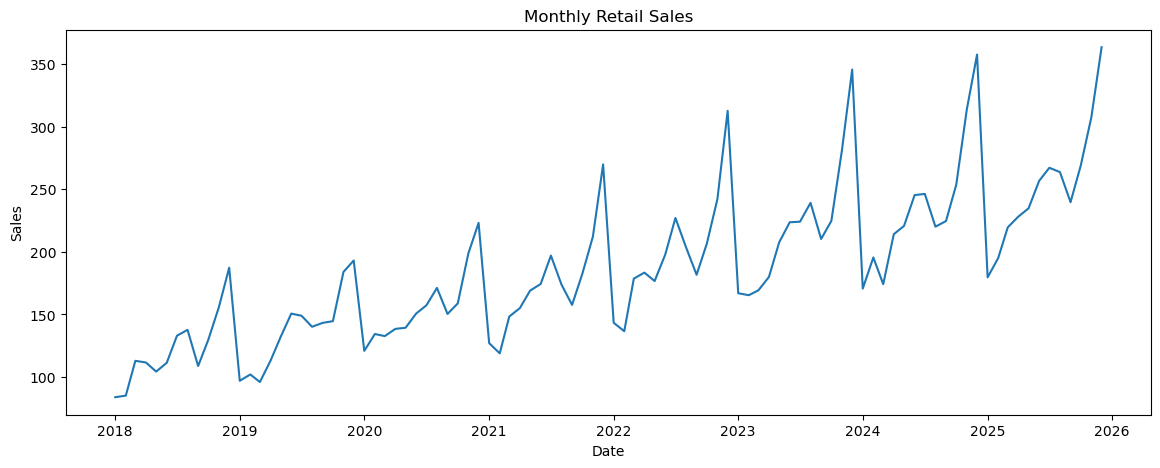

In [3]:
# Part 1: Visualizing the Time Series
# Exercise 2: Plot Monthly Sales
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["sales"])
plt.title("Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Questions
# Look carefully at the graph:

# Is there a trend?
# Yes, there is a clear upward trend.
    
# Is there seasonality?
# Yes, there is a Strong Seasonality.

# Are there unusually high or low observations?
# There are some unusually high and low observations, but they mostly appear to be part of 
# the seasonal pattern rather than random anomalies

# Does the size of seasonal fluctuations appear constant?
# No. The size of the seasonal fluctuations increases over time.
    
# Can you identify months that repeatedly have higher sales?
# At the end of the year has the highest sales, particularly 
# November and December, with December being the strongest peak.

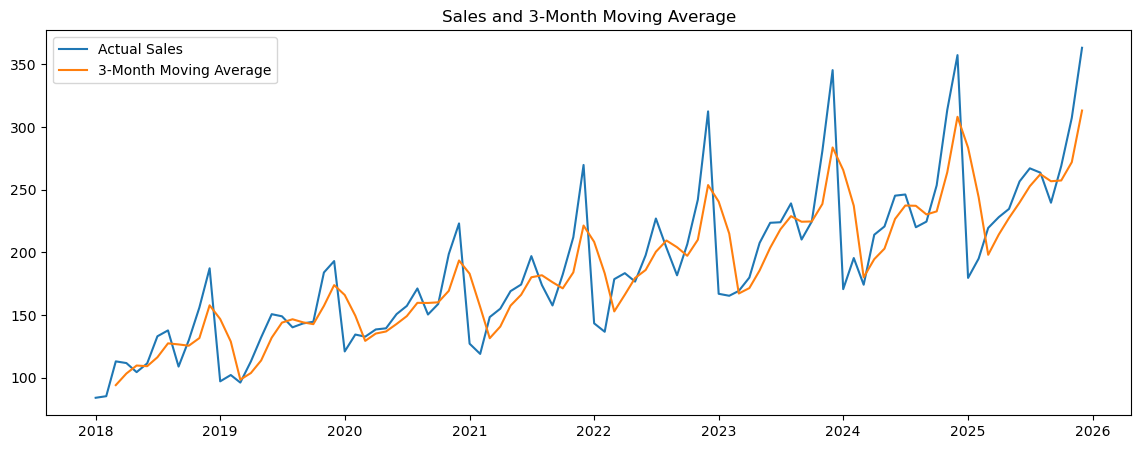

In [4]:
# Part 2: Moving Average
# Exercise 3: Calculate a 3-Month Moving Average
df["MA_3"] = df["sales"].rolling(window=3).mean()
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["sales"], label="Actual Sales")
plt.plot(df.index, df["MA_3"], label="3-Month Moving Average")
plt.legend()
plt.title("Sales and 3-Month Moving Average")
plt.show()

# Questions
# What does the moving average do to the series?
# The 3-month moving average reduces the short-term ups and downs in the actual sales series.

# Is the moving average smoother than the original series?
# Yes, clearly.(Fewer sudden up and down)


# Why are the first observations missing?
# The first two observations are missing because there are not yet three months of data 
# available to calculate the 3-month average.

# Does the moving average remove some random fluctuations?
# Yes, the 3-month moving average removes/reduces some short-term random fluctuations.

# Does it completely remove seasonality?
# No. The 3-month moving average does not completely remove the seasonality.

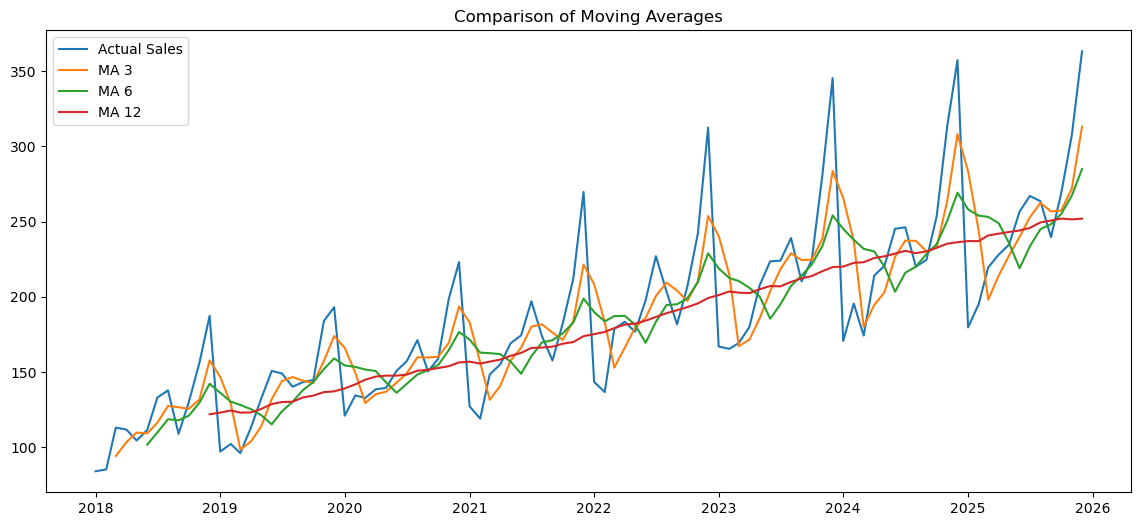

In [5]:
# Exercise 4: Compare Different Moving Averages
df["MA_3"] = df["sales"].rolling(3).mean()
df["MA_6"] = df["sales"].rolling(6).mean()
df["MA_12"] = df["sales"].rolling(12).mean()
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["sales"], label="Actual Sales")
plt.plot(df.index, df["MA_3"], label="MA 3")
plt.plot(df.index, df["MA_6"], label="MA 6")
plt.plot(df.index, df["MA_12"], label="MA 12")
plt.legend()
plt.title("Comparison of Moving Averages")
plt.show()

# Questions
# Compare the 3-month, 6-month, and 12-month moving averages:
# Which window is most responsive to recent changes?
# Answer: 3-month window (MA 3)
          # The MA 3 follows the blue Actual Sales line relatively closely. When sale
          # suddenly increase or decrease, MA 3 reacts relatively quickly.

# Which window produces the smoothest curve?
# Answer: 12-month window (MA 12)
# The MA 12 is much smoother than MA 3 and MA 6.

# Which window removes the most short-term variation?
# Answer: 12-month window (MA 12)
# Short-term variation means small, temporary changes from month to month.

# Which one would be better for identifying the long-term trend?
# Answer: 12-month moving average (MA 12)
# The red MA 12 line shows a gradual upward movement 

# What is the trade-off between a small and large window?
# Small window
#      ↓
# More responsive
#      ↓
# Can detect recent changes quickly
#      ↓
# But more noise remains
############################################
# Large window
#      ↓
# Much smoother
#      ↓
# Removes more noise
#      ↓
# Better for long-term trend
#      ↓
# But reacts slowly to recent changes


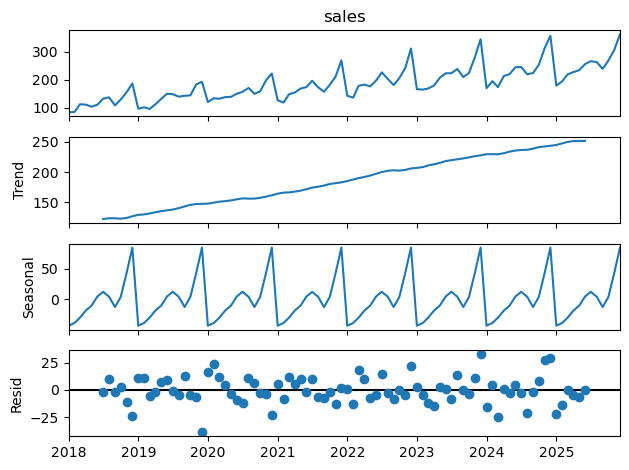

In [6]:
# Part 3: Additive and Multiplicative Decomposition
# Exercise 5: Additive Decomposition
# The additive model assumes: Observed = Trend + Seasonality + Residual
from statsmodels.tsa.seasonal import seasonal_decompose
additive = seasonal_decompose(
 df["sales"],
 model="additive",
 period=12
)
additive.plot()
plt.show()

# Questions
# Examine the four components (Observed, Trend, Seasonal, Residual):
# What is happening to the trend?
    # The trend is clearly increasing over time.
    # At the beginning of 2018, the trend is around 120–125.
    # It gradually increases throughout the years.
    # By 2025, it reaches approximately 250.
    # This indicates that overall sales are growing over time.

# What is the seasonal pattern?
    # The seasonal component shows a strong repeating 12-month pattern.
    # The same pattern appears approximately every year:
    # Sales start with relatively negative seasonal effects.
    # They gradually increase toward positive values.
    # There is a large positive seasonal spike near the end of each yearly cycle.
    # Then the seasonal effect suddenly drops back to a large negative value.
# Is the seasonal effect approximately constant?
    # Yes.
    # The seasonal component has approximately the same magnitude and shape each year.
    # For example, the large positive seasonal peaks remain around +80, while the negative
    # effects are around −40.
    # This is important because the additive model assumes that the seasonal effect remains 
    # approximately constant over time.
    
# What does the residual represent?
    # The residual represents the part of sales that is not explained by the trend or
    # seasonal pattern.
        
    # In the equation:
    # Observed = Trend + Seasonal + Residual
    
    # the residual is essentially:
    # Residual = Observed − Trend − Seasonal
    
    # From the graph:
    # Most residuals are relatively close to zero.
    # Some observations have positive residuals.
    # Some have negative residuals.
    # There are a few relatively large residuals, such as around +30 and −40.

    # These could represent random variation, unusual events, promotions, unexpected 
    # demand,or other factors not captured by the model.

# Which months appear to have positive seasonal effects?
    # December has the strongest positive seasonal effect.
    # the largest positive seasonal effect occurs near the end of each 12-month cycle.

# Which months appear to have negative seasonal effects?
    # The strongest negative seasonal effect occurs immediately after the large positive peak.
    # January → strongly negative
    # February → negative
    # Some other months also have smaller negative effects.

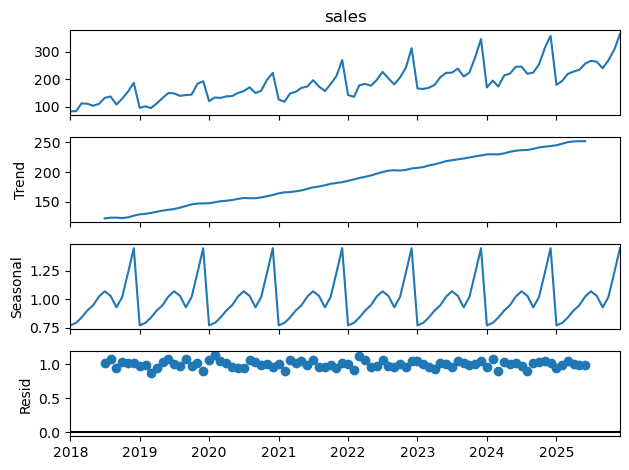

In [7]:
# Exercise 6: Multiplicative Decomposition
# The multiplicative model assumes: Observed = Trend × Seasonality × Residual

multiplicative = seasonal_decompose(
 df["sales"],
 model="multiplicative",
 period=12
)
multiplicative.plot()
plt.show()

# Questions
# How does the multiplicative decomposition differ from the additive decomposition?
    # The main difference is how seasonality affects sales.
    # Additive model:
    # Sales=Trend+Seasonal+Residual
    
    # The seasonal effect is measured as an absolute amount. 
    
    # Multiplicative model:
    # Sales=Trend×Seasonal×Residual
    # The seasonal effect is measured as a proportion or multiplier.

# Does seasonal variation increase as sales increase?
    # Yes, this appears to be the case.

# Is the seasonal pattern proportional to the level of the series?
    # Yes it is propertional
# Does the multiplicative decomposition appear reasonable for this dataset?
    # Yes, the multiplicative decomposition appears reasonable, and arguably more appropriate 
    # than the additive model if the seasonal fluctuations grow with the sales level.

In [8]:
# Exercise 7: Additive vs Multiplicative Comparison
# Complete the following table in your notes:
# Characteristic                                        Additive    Multiplicative
# Basic relationship                                      Observed = Trend + Seasonality + Residual              ?
# Seasonal effect                                           ?              ?
# Seasonal variation constant?                              ?              ?
# Seasonal variation grows with level?                      ?              ?
# Example                                                   ?              ?
# Analytical Prompts:
# Question 1: When should we use additive decomposition?
# Question 2: When should we use multiplicative decomposition?
##########################################################################################
# Answer
# Characteristic	                           Additive                       	Multiplicative
# Basic relationship:	Observed = Trend + Seasonality + Residual	  Observed = Trend × Seasonality × Residual
# Seasonal effect	        :   Fixed/absolute amount	                  Proportional/percentage effect
# Seasonal variation constant?:	Yes, approximately constant          	No, absolute variation changes with the level
# Seasonal variation grows with level?	: No	                                       Yes
# Example	  :         Sales increase by about +50 units every December  	Sales increase by about 20% every December

# Question 1: When should we use additive decomposition?
# Use additive decomposition when the seasonal fluctuations remain approximately constant in size over time,
# regardless of whether the overall level is high or low.

# For example:
# January: 100 sales
# December: 150 sales → +50
# Later, January: 200 sales
# December: 250 sales → still +50
# Here, the seasonal effect is approximately +50 units, so an additive model is appropriate.

# Question 2: When should we use multiplicative decomposition?
# Use multiplicative decomposition when seasonal fluctuations change according to the level of the series.
# For example:
# January: 100 sales
# December: 120 sales → 20% increase
# Later, January: 200 sales
# December: 240 sales → 20% increase
# The absolute seasonal difference increased from 20 to 40, but the percentage effect remained approximately 20%.
# Therefore, a multiplicative model is appropriate.
# Additive = fixed amount
# Multiplicative = fixed percentage

# For sales dataset, the multiplicative decomposition appears reasonable because the
# seasonal component is expressed around 1.0 and the seasonal effect can be interpreted
# proportionally to the increasing sales level.

In [9]:
# Part 4: Stationarity

# Exercise 8: Visual Stationarity Assessment
# Questions
# Does the mean appear constant over time?
    # No.
    # The average sales level is clearly increasing over time.
# Does the variance appear constant?
    # not perfectly constant.
    # The fluctuations around the overall level become larger as the sales level increases.
# Does the series have a trend?
    # Yes, very clearly.
    # The series shows a strong upward trend.
# Does the series have seasonality?
    # Yes.
    # There is a clear repeating pattern approximately every 12 months
# Would you classify the original sales series as stationary or non-stationary?
    # The original sales series is NON-STATIONARY.
    # There are several pieces of evidence:
    # Mean is not constant → sales level increases over time.
    # Variance is not perfectly constant → fluctuations change with the level.
    # Strong upward trend → long-term growth exists.
    # Strong seasonality → repeating 12-month pattern exists.
# Explain your answer using evidence from the graph.
    # The original sales series is non-stationary because the graph shows several clear changes over time:
    # The mean is not constant: At the beginning, sales are mostly around 100–150, while in the later years they are often around 
    # 200–300+. This shows that the average level of the series is increasing.
    # There is a clear upward trend: The sales generally increase from 2018 to 2025, rather than fluctuating around one fixed level.
    # There is strong seasonality: A similar pattern of rises and sharp drops repeats approximately every 12 months, indicating yearly seasonality.
    # The variance is not perfectly constant: The fluctuations become larger as the overall sales level increases. The later years contain larger
    # peaks and drops than the earlier years.

In [10]:
# Exercise 9: Compare Different Periods
# Split the series into three periods and compute summary metrics:

first = df["sales"].iloc[:24]
middle = df["sales"].iloc[24:48]
last = df["sales"].iloc[-24:]
print("First period mean:", first.mean())
print("Middle period mean:", middle.mean())
print("Last period mean:", last.mean())
print("First period std:", first.std())
print("Middle period std:", middle.std())
print("Last period std:", last.std())

# Questions
# Is the mean approximately constant?
    # No. The mean changes substantially over time.
# Is the standard deviation approximately constant?
    # No. The standard deviation also increases.
# What does this tell you about stationarity?
    # It provides strong evidence that the series is non-stationary.
    # For a stationary time series, we generally expect its statistical properties, 
    # particularly mean and variance, to remain relatively stable over time.
# Why is visual inspection alone not always sufficient?
    # Visual inspection is useful for identifying obvious patterns such as:
        # Trend
        # Seasonality
        # Increasing/decreasing variability
        # Outliers
    # However, it has limitations.
    # For example, two periods might look similar on a graph, but their actual means could 
    # be significantly different.

First period mean: 129.50749024391905
Middle period mean: 165.09152388690129
Last period mean: 244.1476883717368
First period std: 30.713317552398202
Middle period std: 35.52279961514827
Last period std: 51.18185662970535


In [11]:
# Part 5: Augmented Dickey-Fuller (ADF) Test
    # H0: Unit root exists ──► Series is non-stationary
    # H1: No unit root ──► Series is stationary
    # Decision Rule:
    # p-value < 0.05 ──► Reject H0 ──► Stationary
    # p-value > 0.05 ──► Fail to reject H0 ──► Non-stationary

In [12]:
# Exercise 10: Perform the ADF Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["sales"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
 print(f"Critical Value ({key}): {value}")
    
# Questions
# What is the ADF statistic?
    # The ADF statistic is the test statistic used to determine whether there is evidence 
    # against the unit-root null hypothesis.
    # 0.0320
    
# What is the p-value?
    # The p-value is:0.9611or approximately:96.11%
    # We compare this with the significance level, usually 0.05 (5%).
    # 0.9611>0.05
    
# What is the null hypothesis?
   #  The null hypothesis of the ADF test is:
   #       H0:The series has a unit root
   #  A unit root indicates that the series is non-stationary.
   #  Therefore:H₀ → Unit root exists → Series is non-stationary
   #  The alternative hypothesis is:
   #      H1:The series has no unit root
   # Therefore:H₁ → No unit root → Series is stationary

# Do you reject or fail to reject the null hypothesis?
    # α=0.05
    # Your p-value is:0.9611
    # Since:0.9611>0.05
    # we:Fail to reject H0
    
# Is the original sales series stationary?
    # No.
    # The original sales series is:NON-STATIONARY
    # The evidence is:
    # ADF statistic = 0.0320
    # p-value = 0.9611
    # p-value > 0.05
    # Therefore, fail to reject H₀
    # H₀ indicates a unit root
    # Therefore, the series is non-stationary
    # We can also compare the ADF statistic with the 5% critical value:0.0320>−2.8966
    # The ADF statistic is not more negative than the critical value, so we again fail 
    # to reject H0
	

ADF Statistic: 0.03202228163187008
p-value: 0.9611015371515231
Critical Value (1%): -3.510711795769895
Critical Value (5%): -2.8966159448223734
Critical Value (10%): -2.5854823866213152


In [13]:
# Exercise 11: Interpret ADF Results
# Questions
    # Is 0.53 < 0.05 ?
        # No.
        # 0.53>0.05
        # Therefore:0.53<0.05 is FALSE

    # Should H0 be rejected?
        # No.
        # Because:
        # p-value=0.53>0.05
        # Fail to reject H0

    # Does the result provide evidence of stationarity?
        # No.
        # The ADF test's null hypothesis is:
        # H0:Unit root exists → Non-stationary
        # Since we failed to reject H0
        # , there is not enough statistical evidence to conclude that the series is stationary.
        # Therefore:The series is considered non-stationary


    # What should you do next?
        # Since the series appears non-stationary, you should generally transform it to achieve 
        # stationarity before using models that require stationary data.
        # A common next step is differencing:
        # Yt′=Yt−Yt−1


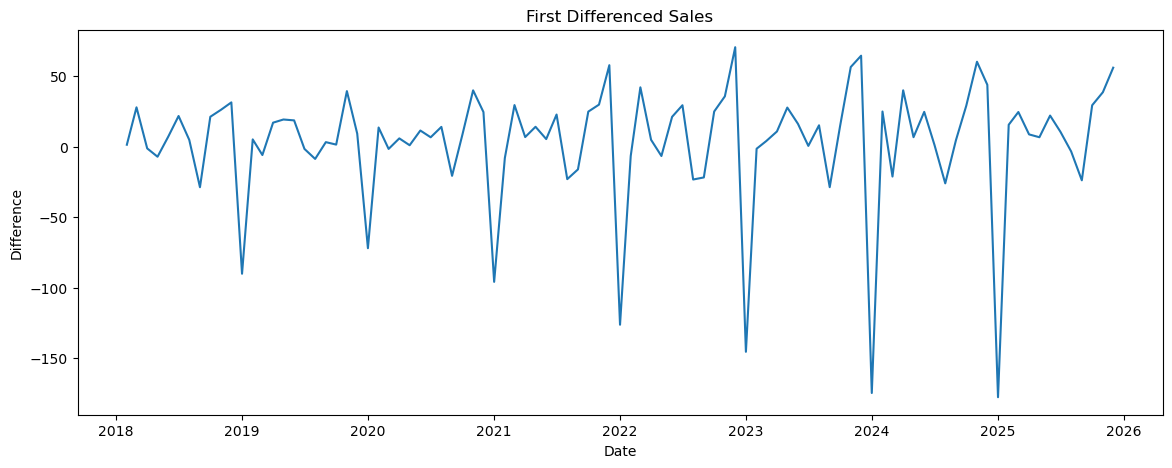

In [14]:
# Part 6: Differencing
# Exercise 12: First-Order Differencing
df["sales_diff"] = df["sales"].diff()
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["sales_diff"])
plt.title("First Differenced Sales")
plt.xlabel("Date")
plt.ylabel("Difference")
plt.show()

# Questions
# Did differencing reduce the trend?
    # Yes, significantly. 
    # The original sales series had a clear upward trend from 2018 to 2025.
    # After first-order differencing, the series no longer shows a consistent upward movement.
    # Instead, it fluctuates around approximately zero.

# Does the series look more stable?
    # Yes, compared with the original series. 
    # The original sales values increased from roughly 100–150 to 200–300+.
    # After differencing, the values generally fluctuate around zero, mostly within a
    # range of approximately −50 to +50, although there are some large negative changes.

# What happened to the first observation?
    # The first observation became:NaN

# Why is the first observation missing?
    # Because .diff() calculates:Yt−Yt−1
    # For the first observation, Yt−1 does not exist.

# Does seasonality still appear?
    # Yes, some seasonal structure appears to remain. 

In [15]:
# Exercise 13: ADF Test After Differencing
result_diff = adfuller(df["sales_diff"].dropna())
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
for key, value in result_diff[4].items():
 print(f"Critical Value ({key}): {value}")
# Questions
# Did the p-value change?
    # Yes — dramatically. 
# Is the differenced series stationary?
    # Yes.becuase the p value is exactly 0 and the ADF statistics is less than critical value
# How many differences were required?
    # Only one difference was required to achieve stationarity.
# What value of d would you initially consider for ARIMA?
# In an ARIMA model:
# ARIMA(p,d,q)
# the d represents the number of non-seasonal differences applied to make the series stationary.
# Since  original series was non-stationary and became stationary after one difference:
# d=1

ADF Statistic: -22.788748410220506
p-value: 0.0
Critical Value (1%): -3.510711795769895
Critical Value (5%): -2.8966159448223734
Critical Value (10%): -2.5854823866213152


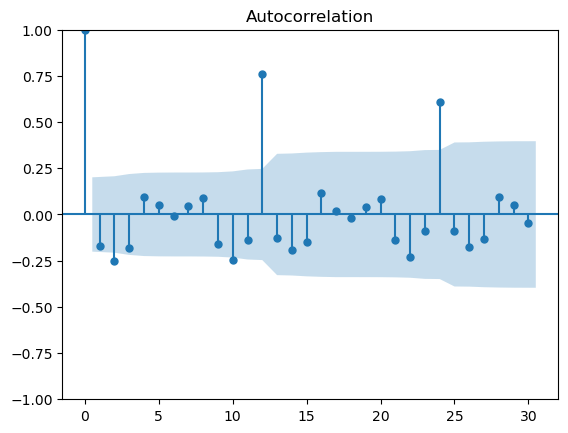

In [16]:
# Part 7: Autocorrelation Function (ACF)
# Exercise 14: Plot ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df["sales_diff"].dropna(),lags=30)
plt.show()
# Questions
# What does lag 1 represent?
    # Lag 1 represents the correlation between the current month's differenced sales
    # and the previous month's differenced sales.

# What does lag 2 represent?
    # Lag 2 represents the correlation between the current month and the differenced
    # sales two months earlier.

# What does lag 12 represent?
    # lag 12 can reveal annual/seasonal autocorrelation.

# Which lags appear significant?
    # with 12 and 24 being especially important because they are multiples of 12.
# Is there evidence of seasonal autocorrelation?
    # Yes — very strong evidence.
    # There is strong 12-month seasonal autocorrelation
# Does the ACF cut off quickly or tail off gradually?
    # The non-seasonal ACF mostly dies down quickly, but strong seasonal spikes remain at 
    # lags 12 and 24.

In [17]:
# Part 8: Partial Autocorrelation Function (PACF)
# PACF measures the relationship between the current value and a particular lag after accounting for the effects of
# intermediate lags.

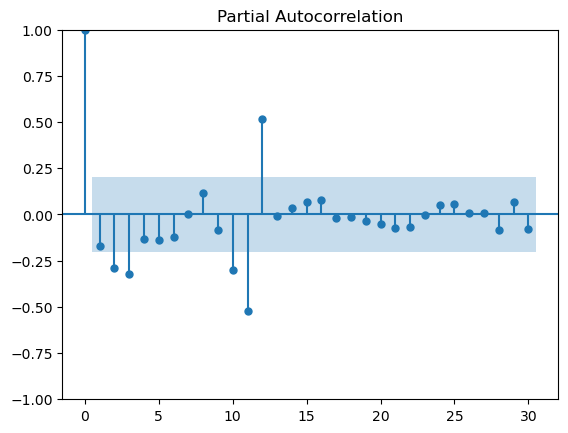

In [21]:
# Exercise 15: Plot PACF
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(
 df["sales_diff"].dropna(),lags=30,method="ywm")
plt.show()
# Questions
# Which lags appear significant?
    # The most important spikes are:
    # Lag 2 → negative
    # Lag 3 → negative
    # Lag 10 → negative
    # Lag 11 → very large negative
    # Lag 12 → very large positive
    # Some of the smaller early negative spikes are close to the confidence boundary,
    # so the strongest evidence is particularly at lags 2, 3, 10, 11, and 12.

# Does PACF cut off quickly?
    # No. The PACF does not cut off quickly because significant spikes appear up to around Lag 12.
# Does PACF tail off?
    # Yes, approximately. After Lag 12, most PACF values become small and remain 
    # within the confidence interval.
# What AR order might you initially consider?
    # An initial candidate could be AR(12), although lower orders such as AR(2) or AR(3)
    # should also be tested and compared using AIC/BIC and residual diagnostics.
# Is there evidence of seasonal dependence?
    # Yes. The strong spike at Lag 12, together with the strong ACF spikes at Lags 12
    # and 24, provides evidence of a 12-period seasonal pattern. If the data is monthly,
    # this indicates possible annual seasonality..

In [22]:
# Part 9: ARIMA Models
    # ARIMA stands for AutoRegressive Integrated Moving Average: ARIMA(p, d, q) where
    # p = AR order, d=differencing order, and q = MA order

# Exercise 16: Train-Test Split
train = df["sales"].iloc[:-12]
test = df["sales"].iloc[-12:]
print("Training observations:", len(train))
print("Testing observations:", len(test))

# Questions
# Why should we keep a test set?
    # The test set allows us to evaluate how well the model performs on data it 
    # has never seen during training.
# Why should time-series data not normally be randomly shuffled before splitting?
    # If you randomly shuffle the observations, you could put future observations into
    # the training set while putting earlier observations into the test set.
# Why are the most recent observations useful as a test set?
    # Because the most recent observations are the closest representation of
    # the future that we actually want to forecast.

Training observations: 84
Testing observations: 12


In [23]:
# Exercise 17: Build Your First ARIMA Model
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train,order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())
    # Structure Breakdown:
    # ARIMA(1, 1, 1)
    #  │ │ └── MA = 1 (Moving Average order q)
    #  │ └──── Differencing = 1 (Integration order d)
    #  └────── AR = 1 (Autoregressive order p) 
# Questions
# What does p=1 mean?
    # p is the autoregressive (AR) order.
    # The current change in sales depends partly on the previous change in sales.
# What does d=1 mean?
    # d=1 means we difference the original series once to remove the non-stationarity/trend.
# What does q=1 mean?
    # q is the Moving Average (MA) order.
    # the model uses one previous forecast error/residual to help predict the current value.
# Why did we use d=1 ?
    # Because the original series was non-stationary, while one difference made it stationary.
# How did ACF and PACF help us choose candidate values for p and q ?
    # PACF → helps identify p
    # ACF → helps identify q

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA param

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -417.437
Date:                Wed, 19 Aug 2026   AIC                            840.874
Time:                        13:58:03   BIC                            848.130
Sample:                    01-01-2018   HQIC                           843.789
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3822      0.266      1.436      0.151      -0.139       0.904
ma.L1         -0.8561      0.170     -5.038      0.000      -1.189      -0.523
sigma2      1356.3031    167.471      8.099      0.0

2025-01-01    302.140859
2025-02-01    281.008797
2025-03-01    272.932319
2025-04-01    269.845564
2025-05-01    268.665835
2025-06-01    268.214953
2025-07-01    268.042630
2025-08-01    267.976770
2025-09-01    267.951599
2025-10-01    267.941979
2025-11-01    267.938302
2025-12-01    267.936897
Freq: MS, Name: predicted_mean, dtype: float64


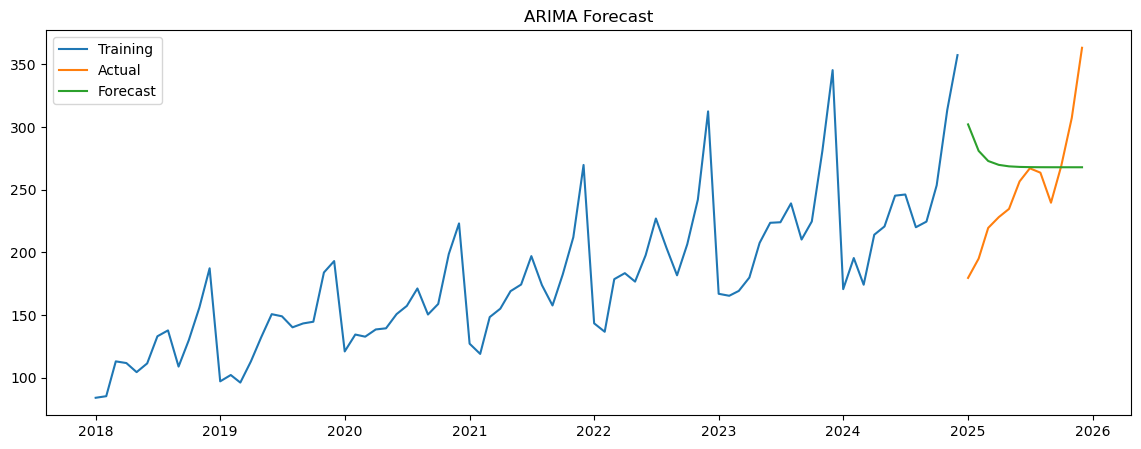

In [24]:
# Exercise 18: Forecast the Test Period
forecast = model_fit.forecast(steps=12)
print(forecast)
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()
# Questions
# Does the forecast follow the general direction of the actual series?
    # Partially, but not very well.
# Does it capture the seasonal behavior?
    # No, not well. 
# Where does the model make large errors?
    # There are several obvious areas.
    # Early 2025
# What does ARIMA appear to struggle with?
    # Strong seasonality
    # ARIMA(1,1,1) is a non-seasonal ARIMA model.
    # The data has strong yearly seasonality:
    # s=12
    # Therefore, ordinary ARIMA struggles to reproduce those repeated seasonal peaks and drops

In [25]:
# Part 10: ARIMA Evaluation
# Exercise 19: Calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(test, forecast)
print("MAE:", mae)
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)
# Questions
# What does MAE measure?
    # MAE = Mean Absolute Error
    # It calculates the average absolute difference between the actual and predicted values.

# What does RMSE measure?
    # RMSE = Root Mean Squared Error
    # It measures the square root of the average squared prediction errors

# Which metric is more sensitive to large errors?
    # RMSE:This is because RMSE squares the errors.

# Is a lower or higher MAE better?
    # Lower MAE is better

# Is a lower or higher RMSE better?
    # Lower RMSE is better

MAE: 43.204813315869934
RMSE: 57.54898339115396


In [26]:
# ============================================================
# PART 11: SARIMA MODELS
# EXERCISE 20: BUILD A SARIMA MODEL
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
# SARIMA(1,1,1)(1,1,1,12)
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

model_fit = model.fit(disp=False)

print(model_fit.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -290.562
Date:                            Wed, 19 Aug 2026   AIC                            591.124
Time:                                    14:42:45   BIC                            602.437
Sample:                                01-01-2018   HQIC                           595.623
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0645      0.159      0.406      0.685      -0.247       0.376
ma.L1         -0.9860      0.121   

In [27]:
# ============================================================
# EXERCISE 20: ANSWERS
# ============================================================

print("""
EXERCISE 20 ANSWERS
===================

1. What does the first (1,1,1) represent?

The first (1,1,1) represents the non-seasonal ARIMA components:

p = 1 → One non-seasonal autoregressive term (AR)
d = 1 → One non-seasonal difference
q = 1 → One non-seasonal moving-average term (MA)


2. What does (1,1,1,12) represent?

It represents the seasonal components:

P = 1 → One seasonal autoregressive term
D = 1 → One seasonal difference
Q = 1 → One seasonal moving-average term
s = 12 → Seasonal period of 12 observations


3. Why is the seasonal period 12?

The dataset contains monthly sales data. There are 12 months
in one year, so a yearly seasonal pattern has a period of 12.


4. Why might SARIMA be more appropriate than ARIMA for this dataset?

SARIMA explicitly models seasonality, while ordinary ARIMA
does not contain seasonal AR, differencing, or MA components.

Our previous ACF and PACF analysis showed strong seasonal
dependence around lag 12. Therefore, SARIMA is more appropriate
for modeling the yearly seasonal pattern.


5. What is the main difference between ARIMA and SARIMA?

ARIMA models non-seasonal patterns:

ARIMA(p,d,q)

SARIMA models both non-seasonal and seasonal patterns:

SARIMA(p,d,q)(P,D,Q,s)
""")


EXERCISE 20 ANSWERS

1. What does the first (1,1,1) represent?

The first (1,1,1) represents the non-seasonal ARIMA components:

p = 1 → One non-seasonal autoregressive term (AR)
d = 1 → One non-seasonal difference
q = 1 → One non-seasonal moving-average term (MA)


2. What does (1,1,1,12) represent?

It represents the seasonal components:

P = 1 → One seasonal autoregressive term
D = 1 → One seasonal difference
Q = 1 → One seasonal moving-average term
s = 12 → Seasonal period of 12 observations


3. Why is the seasonal period 12?

The dataset contains monthly sales data. There are 12 months
in one year, so a yearly seasonal pattern has a period of 12.


4. Why might SARIMA be more appropriate than ARIMA for this dataset?

SARIMA explicitly models seasonality, while ordinary ARIMA
does not contain seasonal AR, differencing, or MA components.

Our previous ACF and PACF analysis showed strong seasonal
dependence around lag 12. Therefore, SARIMA is more appropriate
for modeling the yearl

In [28]:
# ============================================================
# EXERCISE 21: FORECAST WITH SARIMA
# ============================================================

forecast_sarima = model_fit.forecast(steps=12)

print("SARIMA Forecast:")
print(forecast_sarima)

SARIMA Forecast:
2025-01-01    193.713094
2025-02-01    212.022102
2025-03-01    199.446273
2025-04-01    231.881174
2025-05-01    240.918782
2025-06-01    263.450032
2025-07-01    266.500579
2025-08-01    247.037852
2025-09-01    244.427826
2025-10-01    270.671123
2025-11-01    327.851551
2025-12-01    376.121519
Freq: MS, Name: predicted_mean, dtype: float64


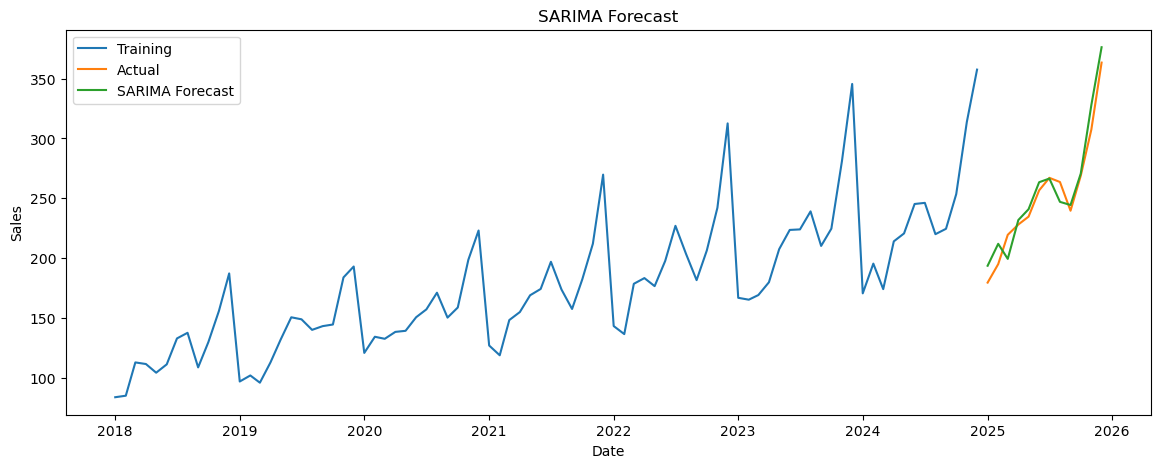

In [29]:
# ============================================================
# PLOT SARIMA FORECAST
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    forecast_sarima,
    label="SARIMA Forecast"
)

plt.legend()
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [30]:
# ============================================================
# EXERCISE 21: ANSWERS
# ============================================================

print("""
EXERCISE 21 ANSWERS
===================

1. Does SARIMA capture seasonal behavior better than ARIMA?

SARIMA is expected to capture seasonal behavior better because
it explicitly includes seasonal AR, differencing, and MA terms
with a seasonal period of 12.

This is especially appropriate because the ACF showed strong
spikes around lag 12 and lag 24.


2. Does the forecast follow the actual data?

This should be determined from the forecast graph and the
MAE/RMSE values calculated in Exercise 22.

A good forecast should follow the general direction, level,
and seasonal fluctuations of the actual observations.


3. Where does the model make large errors?

Large errors occur where the actual sales have sudden peaks,
drops, or unusual movements that the model cannot reproduce.

Compare the SARIMA forecast with the actual test observations
to identify these periods.


4. Overall conclusion:

SARIMA should generally be more capable of reproducing the
yearly seasonal pattern than the non-seasonal ARIMA(1,1,1),
but actual performance must be confirmed using MAE and RMSE.
""")


EXERCISE 21 ANSWERS

1. Does SARIMA capture seasonal behavior better than ARIMA?

SARIMA is expected to capture seasonal behavior better because
it explicitly includes seasonal AR, differencing, and MA terms
with a seasonal period of 12.

This is especially appropriate because the ACF showed strong
spikes around lag 12 and lag 24.


2. Does the forecast follow the actual data?

This should be determined from the forecast graph and the
MAE/RMSE values calculated in Exercise 22.

A good forecast should follow the general direction, level,
and seasonal fluctuations of the actual observations.


3. Where does the model make large errors?

Large errors occur where the actual sales have sudden peaks,
drops, or unusual movements that the model cannot reproduce.

Compare the SARIMA forecast with the actual test observations
to identify these periods.


4. Overall conclusion:

SARIMA should generally be more capable of reproducing the
yearly seasonal pattern than the non-seasonal ARIMA(1,1,1),

In [31]:
# ============================================================
# EXERCISE 22: EVALUATE SARIMA
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_sarima = mean_absolute_error(
    test,
    forecast_sarima
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test,
        forecast_sarima
    )
)

print("SARIMA MAE :", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

SARIMA MAE : 10.406906478090526
SARIMA RMSE: 12.491477688972406


In [32]:
# ============================================================
# EXERCISE 22: INTERPRETATION
# ============================================================

print(f"""
SARIMA EVALUATION
=================

MAE  = {mae_sarima:.4f}
RMSE = {rmse_sarima:.4f}

Interpretation:

MAE measures the average absolute forecasting error.

RMSE measures forecasting error while giving greater penalty
to large errors.

For both metrics:

Lower MAE  → Better forecasting performance
Lower RMSE → Better forecasting performance

Therefore, the SARIMA model should be compared with ARIMA
using both MAE and RMSE.
""")


SARIMA EVALUATION

MAE  = 10.4069
RMSE = 12.4915

Interpretation:

MAE measures the average absolute forecasting error.

RMSE measures forecasting error while giving greater penalty
to large errors.

For both metrics:

Lower MAE  → Better forecasting performance
Lower RMSE → Better forecasting performance

Therefore, the SARIMA model should be compared with ARIMA
using both MAE and RMSE.



In [33]:
# ============================================================
# EXERCISE 23: COMPARE ARIMA AND SARIMA
# ============================================================

comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [mae, mae_sarima],
    "RMSE": [rmse, rmse_sarima]
})

print(comparison)

    Model        MAE       RMSE
0   ARIMA  43.204813  57.548983
1  SARIMA  10.406906  12.491478


In [34]:
# ============================================================
# EXERCISE 23: AUTOMATIC COMPARISON
# ============================================================

best_mae_model = comparison.loc[
    comparison["MAE"].idxmin(),
    "Model"
]

best_rmse_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("Model with lower MAE :", best_mae_model)
print("Model with lower RMSE:", best_rmse_model)

print("""
INTERPRETATION
==============

The model with the lower MAE has the smaller average absolute
forecasting error.

The model with the lower RMSE has the smaller error after giving
extra importance to large forecasting errors.

Because our dataset contains strong 12-month seasonality,
SARIMA has a structural advantage over ordinary ARIMA when
the seasonal component is important.
""")

Model with lower MAE : SARIMA
Model with lower RMSE: SARIMA

INTERPRETATION

The model with the lower MAE has the smaller average absolute
forecasting error.

The model with the lower RMSE has the smaller error after giving
extra importance to large forecasting errors.

Because our dataset contains strong 12-month seasonality,
SARIMA has a structural advantage over ordinary ARIMA when
the seasonal component is important.



In [35]:
# ============================================================
# EXERCISE 23: ANSWERS
# ============================================================

print(f"""
EXERCISE 23 ANSWERS
===================
1. Which model has lower MAE?

Answer: {best_mae_model}

2. Which model has lower RMSE?

Answer: {best_rmse_model}

3. Which model better captures seasonality?

SARIMA is designed specifically to model seasonality.
Therefore, SARIMA is expected to capture the 12-month seasonal
pattern better than ordinary ARIMA.

4. Why might SARIMA outperform ARIMA?

SARIMA explicitly includes seasonal AR, seasonal differencing,
and seasonal MA components. This allows it to model the strong
yearly pattern identified in the ACF and PACF analysis.

5. Does a more complicated model always guarantee better
forecasting?

No. A more complicated model does not automatically guarantee
better forecasting. It may overfit the training data and perform
worse on unseen data.

Model complexity should be justified using forecast accuracy,
AIC/BIC, residual diagnostics, and out-of-sample performance.

6. What would happen if the dataset had no seasonality?

If the dataset had no meaningful seasonal pattern, SARIMA would
usually provide little or no advantage over ARIMA. In that case,
ordinary ARIMA would generally be simpler and more appropriate.
""")


EXERCISE 23 ANSWERS

1. Which model has lower MAE?

Answer: SARIMA

2. Which model has lower RMSE?

Answer: SARIMA

3. Which model better captures seasonality?

SARIMA is designed specifically to model seasonality.
Therefore, SARIMA is expected to capture the 12-month seasonal
pattern better than ordinary ARIMA.

4. Why might SARIMA outperform ARIMA?

SARIMA explicitly includes seasonal AR, seasonal differencing,
and seasonal MA components. This allows it to model the strong
yearly pattern identified in the ACF and PACF analysis.

5. Does a more complicated model always guarantee better
forecasting?

No. A more complicated model does not automatically guarantee
better forecasting. It may overfit the training data and perform
worse on unseen data.

Model complexity should be justified using forecast accuracy,
AIC/BIC, residual diagnostics, and out-of-sample performance.

6. What would happen if the dataset had no seasonality?

If the dataset had no meaningful seasonal pattern, SARIMA w

In [36]:
# ============================================================
# PART 12: MODEL EXPERIMENTATION
# EXERCISE 24: TRY DIFFERENT ARIMA MODELS
# ============================================================
from statsmodels.tsa.arima.model import ARIMA
arima_orders = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

arima_results = []
for order in arima_orders:
    try:
        print(f"Training ARIMA{order}...")
        arima_model = ARIMA(train,order=order)
        arima_fit = arima_model.fit()
        arima_forecast = arima_fit.forecast(steps=12)
        arima_mae = mean_absolute_error(test,arima_forecast)
        arima_rmse = np.sqrt(mean_squared_error(test,arima_forecast))
        arima_results.append({
            "Model": f"ARIMA{order}",
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "AIC": arima_fit.aic,
            "BIC": arima_fit.bic,
            "MAE": arima_mae,
            "RMSE": arima_rmse})
        print(
            f"MAE={arima_mae:.4f}, "
            f"RMSE={arima_rmse:.4f}")
    except Exception as e:
        print(f"ARIMA{order} failed: {e}")
arima_comparison = pd.DataFrame(arima_results)
print("\nARIMA MODEL COMPARISON")
print(arima_comparison)

Training ARIMA(0, 1, 1)...
MAE=51.9540, RMSE=59.4725
Training ARIMA(1, 1, 0)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

MAE=101.2212, RMSE=109.8011
Training ARIMA(1, 1, 1)...
MAE=43.2048, RMSE=57.5490
Training ARIMA(2, 1, 1)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA param

MAE=38.3624, RMSE=51.4643
Training ARIMA(1, 1, 2)...
MAE=41.1176, RMSE=55.2151
Training ARIMA(2, 1, 2)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

MAE=28.4159, RMSE=42.0523

ARIMA MODEL COMPARISON
            Model  p  d  q         AIC         BIC         MAE        RMSE
0  ARIMA(0, 1, 1)  0  1  1  847.565678  852.403359   51.953995   59.472534
1  ARIMA(1, 1, 0)  1  1  0  853.506411  858.344092  101.221211  109.801149
2  ARIMA(1, 1, 1)  1  1  1  840.873678  848.130200   43.204813   57.548983
3  ARIMA(2, 1, 1)  2  1  1  838.795907  848.471269   38.362368   51.464310
4  ARIMA(1, 1, 2)  1  1  2  840.747490  850.422853   41.117597   55.215140
5  ARIMA(2, 1, 2)  2  1  2  830.908270  843.002473   28.415939   42.052348


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [37]:
# ============================================================
# BEST ARIMA MODEL
# ============================================================
best_arima = arima_comparison.iloc[0]

print(f"""
BEST ARIMA MODEL
================

Model : {best_arima["Model"]}
AIC   : {best_arima["AIC"]:.4f}
BIC   : {best_arima["BIC"]:.4f}
MAE   : {best_arima["MAE"]:.4f}
RMSE  : {best_arima["RMSE"]:.4f}

The model above has the lowest RMSE among the tested ARIMA
candidate models.
""")


BEST ARIMA MODEL

Model : ARIMA(0, 1, 1)
AIC   : 847.5657
BIC   : 852.4034
MAE   : 51.9540
RMSE  : 59.4725

The model above has the lowest RMSE among the tested ARIMA
candidate models.



In [38]:
# ============================================================
# EXERCISE 24: ANSWERS
# ============================================================

print("""
EXERCISE 24 ANSWERS
===================

We tested six ARIMA configurations:

1. ARIMA(0,1,1)
2. ARIMA(1,1,0)
3. ARIMA(1,1,1)
4. ARIMA(2,1,1)
5. ARIMA(1,1,2)
6. ARIMA(2,1,2)

The results should be compared using MAE and RMSE.

Lower MAE  → Better
Lower RMSE → Better

The model with the lowest RMSE is selected as the best
ARIMA candidate for this experiment.

Note:
AIC and BIC can also be considered, but out-of-sample
forecasting performance is especially important because
our goal is forecasting future sales.
""")


EXERCISE 24 ANSWERS

We tested six ARIMA configurations:

1. ARIMA(0,1,1)
2. ARIMA(1,1,0)
3. ARIMA(1,1,1)
4. ARIMA(2,1,1)
5. ARIMA(1,1,2)
6. ARIMA(2,1,2)

The results should be compared using MAE and RMSE.

Lower MAE  → Better
Lower RMSE → Better

The model with the lowest RMSE is selected as the best
ARIMA candidate for this experiment.

Note:
AIC and BIC can also be considered, but out-of-sample
forecasting performance is especially important because
our goal is forecasting future sales.



In [39]:
# ============================================================
# EXERCISE 25: TRY DIFFERENT SARIMA MODELS
# ============================================================

sarima_orders = [
    ((1, 1, 1), (1, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12))
]

sarima_results = []

for order, seasonal_order in sarima_orders:

    try:
        print(
            f"Training SARIMA{order}"
            f"{seasonal_order}..."
        )

        sarima_model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order
        )

        sarima_fit = sarima_model.fit(
            disp=False
        )

        sarima_forecast = sarima_fit.forecast(
            steps=12
        )

        sarima_mae = mean_absolute_error(
            test,
            sarima_forecast
        )

        sarima_rmse = np.sqrt(
            mean_squared_error(
                test,
                sarima_forecast
            )
        )

        sarima_results.append({
            "Model": (
                f"SARIMA{order}"
                f"{seasonal_order}"
            ),
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": sarima_fit.aic,
            "BIC": sarima_fit.bic,
            "MAE": sarima_mae,
            "RMSE": sarima_rmse
        })

        print(
            f"MAE={sarima_mae:.4f}, "
            f"RMSE={sarima_rmse:.4f}, "
            f"AIC={sarima_fit.aic:.4f}"
        )

    except Exception as e:
        print(
            f"SARIMA{order}"
            f"{seasonal_order} failed: {e}"
        )

sarima_comparison = pd.DataFrame(
    sarima_results
)

print("\nSARIMA MODEL COMPARISON")
print(
    sarima_comparison[
        ["Model", "AIC", "BIC", "MAE", "RMSE"]
    ].to_string(index=False)
)

Training SARIMA(1, 1, 1)(1, 1, 1, 12)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE=10.4069, RMSE=12.4915, AIC=591.1240
Training SARIMA(0, 1, 1)(1, 1, 1, 12)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE=10.6140, RMSE=12.6640, AIC=589.3873
Training SARIMA(1, 1, 0)(1, 1, 1, 12)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE=15.3063, RMSE=16.7767, AIC=616.1015
Training SARIMA(1, 1, 1)(0, 1, 1, 12)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE=10.5894, RMSE=12.6937, AIC=589.2171

SARIMA MODEL COMPARISON
                       Model        AIC        BIC       MAE      RMSE
SARIMA(1, 1, 1)(1, 1, 1, 12) 591.124036 602.437435 10.406906 12.491478
SARIMA(0, 1, 1)(1, 1, 1, 12) 589.387273 598.437993 10.614015 12.664038
SARIMA(1, 1, 0)(1, 1, 1, 12) 616.101481 625.152200 15.306270 16.776722
SARIMA(1, 1, 1)(0, 1, 1, 12) 589.217115 598.267834 10.589407 12.693663


In [40]:
# ============================================================
# SORT SARIMA MODELS BY RMSE
# ============================================================

sarima_comparison = sarima_comparison.sort_values(by="RMSE").reset_index(drop=True)
print("SARIMA MODELS SORTED BY RMSE")
print(sarima_comparison[["Model", "AIC", "BIC", "MAE", "RMSE"]].to_string(index=False))

SARIMA MODELS SORTED BY RMSE
                       Model        AIC        BIC       MAE      RMSE
SARIMA(1, 1, 1)(1, 1, 1, 12) 591.124036 602.437435 10.406906 12.491478
SARIMA(0, 1, 1)(1, 1, 1, 12) 589.387273 598.437993 10.614015 12.664038
SARIMA(1, 1, 1)(0, 1, 1, 12) 589.217115 598.267834 10.589407 12.693663
SARIMA(1, 1, 0)(1, 1, 1, 12) 616.101481 625.152200 15.306270 16.776722


In [41]:
# ============================================================
# BEST SARIMA MODEL
# ============================================================

best_sarima = sarima_comparison.iloc[0]

print(f"""
BEST SARIMA MODEL
=================

Model : {best_sarima["Model"]}
AIC   : {best_sarima["AIC"]:.4f}
BIC   : {best_sarima["BIC"]:.4f}
MAE   : {best_sarima["MAE"]:.4f}
RMSE  : {best_sarima["RMSE"]:.4f}

The model above has the lowest RMSE among the tested SARIMA
candidate models.
""")


BEST SARIMA MODEL

Model : SARIMA(1, 1, 1)(1, 1, 1, 12)
AIC   : 591.1240
BIC   : 602.4374
MAE   : 10.4069
RMSE  : 12.4915

The model above has the lowest RMSE among the tested SARIMA
candidate models.



In [42]:
# ============================================================
# EXERCISE 25: ANSWERS
# ============================================================

best_aic_model = sarima_comparison.loc[sarima_comparison["AIC"].idxmin(),"Model"]
best_mae_model = sarima_comparison.loc[sarima_comparison["MAE"].idxmin(),"Model"]
best_rmse_model = sarima_comparison.loc[sarima_comparison["RMSE"].idxmin(),"Model"]

print(f"""
EXERCISE 25 ANSWERS
===================

1. Which model has the lowest AIC?

{best_aic_model}


2. Which model has the lowest MAE?

{best_mae_model}


3. Which model has the lowest RMSE?

{best_rmse_model}


4. Do the same models always win on all metrics?

No.

A model can have the lowest AIC but not necessarily the lowest
MAE or RMSE. AIC evaluates model fit while penalizing model
complexity, whereas MAE and RMSE evaluate out-of-sample
forecasting errors.


5. Which model would you choose and why?

For this forecasting task, the model with the lowest RMSE is
a strong candidate because RMSE directly evaluates forecasting
performance and gives greater penalty to large errors.

However, AIC/BIC and residual diagnostics should also be checked
before making the final decision.
""")


EXERCISE 25 ANSWERS

1. Which model has the lowest AIC?

SARIMA(1, 1, 1)(0, 1, 1, 12)


2. Which model has the lowest MAE?

SARIMA(1, 1, 1)(1, 1, 1, 12)


3. Which model has the lowest RMSE?

SARIMA(1, 1, 1)(1, 1, 1, 12)


4. Do the same models always win on all metrics?

No.

A model can have the lowest AIC but not necessarily the lowest
MAE or RMSE. AIC evaluates model fit while penalizing model
complexity, whereas MAE and RMSE evaluate out-of-sample
forecasting errors.


5. Which model would you choose and why?

For this forecasting task, the model with the lowest RMSE is
a strong candidate because RMSE directly evaluates forecasting
performance and gives greater penalty to large errors.

However, AIC/BIC and residual diagnostics should also be checked
before making the final decision.



In [43]:
# ============================================================
# PART 13: FINAL FORECASTING CHALLENGE
# EXERCISE 26: GET BEST SARIMA PARAMETERS
# ============================================================

best_order = best_sarima["order"]
best_seasonal_order = best_sarima["seasonal_order"]
print("Best non-seasonal order:", best_order)
print("Best seasonal order:", best_seasonal_order)

Best non-seasonal order: (1, 1, 1)
Best seasonal order: (1, 1, 1, 12)


In [44]:
# ============================================================
# TRAIN FINAL MODEL ON COMPLETE DATASET
# ============================================================
final_model = SARIMAX(df["sales"],order=best_order,seasonal_order=best_seasonal_order)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -337.398
Date:                            Wed, 19 Aug 2026   AIC                            684.796
Time:                                    14:52:56   BIC                            696.890
Sample:                                01-01-2018   HQIC                           689.654
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0737      0.143      0.516      0.606      -0.206       0.353
ma.L1         -0.9999     10.873   

In [45]:
# ============================================================
# EXERCISE 27: FORECAST THE NEXT 12 MONTHS
# ============================================================

future_forecast = final_fit.forecast(steps=12)
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1),periods=12,freq="MS")
future = pd.DataFrame({
    "date": future_dates,
    "forecast_sales": future_forecast.values})
print("NEXT 12 MONTH SALES FORECAST")
print(future.to_string(index=False))

NEXT 12 MONTH SALES FORECAST
      date  forecast_sales
2026-01-01      204.155952
2026-02-01      218.602919
2026-03-01      233.957832
2026-04-01      247.790148
2026-05-01      255.732364
2026-06-01      276.945117
2026-07-01      285.964870
2026-08-01      279.131039
2026-09-01      260.027123
2026-10-01      287.141935
2026-11-01      330.476534
2026-12-01      384.926877


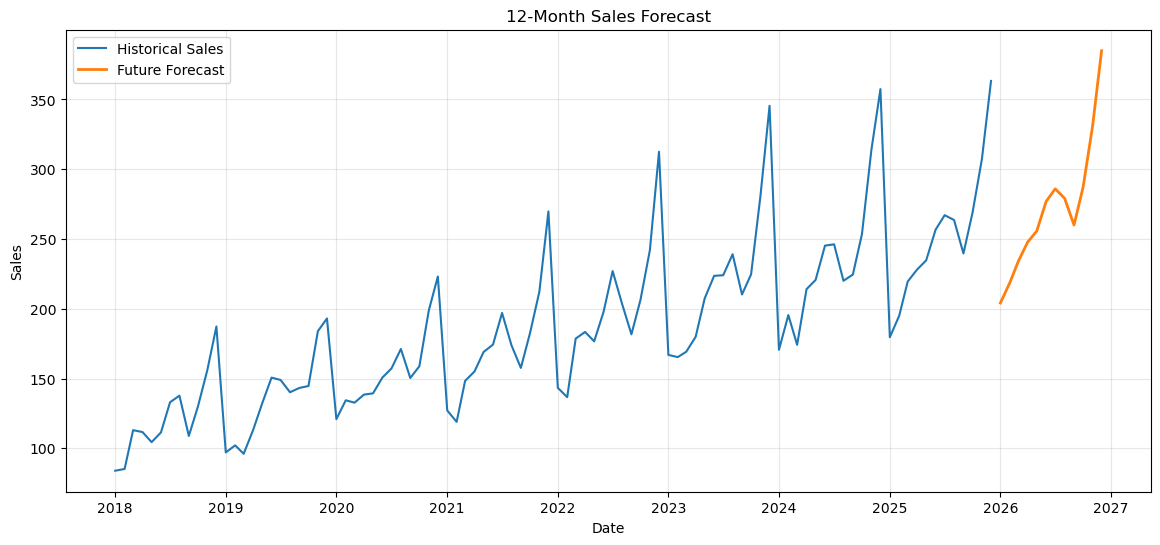

In [46]:
# ============================================================
# EXERCISE 28: PLOT FINAL FORECAST
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(
    df.index,
    df["sales"],
    label="Historical Sales")
plt.plot(
    future["date"],
    future["forecast_sales"],
    label="Future Forecast",
    linewidth=2
)

plt.legend()
plt.title("12-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

In [47]:
# ============================================================
# EXERCISE 28: AUTOMATIC ANALYSIS
# ============================================================

highest_row = future.loc[future["forecast_sales"].idxmax()]
lowest_row = future.loc[future["forecast_sales"].idxmin()]
print(f"""
EXERCISE 28 ANSWERS
===================

1. Predicted sales for each future month:

{future.to_string(index=False)}


2. Which future month has the highest predicted sales?

Date  : {highest_row["date"].strftime("%B %Y")}
Sales : {highest_row["forecast_sales"]:.2f}


3. Which future month has the lowest predicted sales?

Date  : {lowest_row["date"].strftime("%B %Y")}
Sales : {lowest_row["forecast_sales"]:.2f}


4. Can you identify a seasonal pattern?

If the forecast repeatedly rises and falls at approximately
12-month intervals, this indicates seasonal behavior.

Because the model is SARIMA with seasonal period 12, it is
specifically designed to model yearly seasonality.


5. Does the forecast make business sense?

The forecast should be compared with historical sales levels,
the observed trend, and the historical seasonal pattern.

A forecast is more reasonable if it remains within a plausible
range and follows the historical trend and seasonal behavior.
""")


EXERCISE 28 ANSWERS

1. Predicted sales for each future month:

      date  forecast_sales
2026-01-01      204.155952
2026-02-01      218.602919
2026-03-01      233.957832
2026-04-01      247.790148
2026-05-01      255.732364
2026-06-01      276.945117
2026-07-01      285.964870
2026-08-01      279.131039
2026-09-01      260.027123
2026-10-01      287.141935
2026-11-01      330.476534
2026-12-01      384.926877


2. Which future month has the highest predicted sales?

Date  : December 2026
Sales : 384.93


3. Which future month has the lowest predicted sales?

Date  : January 2026
Sales : 204.16


4. Can you identify a seasonal pattern?

If the forecast repeatedly rises and falls at approximately
12-month intervals, this indicates seasonal behavior.

Because the model is SARIMA with seasonal period 12, it is
specifically designed to model yearly seasonality.


5. Does the forecast make business sense?

The forecast should be compared with historical sales levels,
the observed trend, a

In [48]:
# ============================================================
# EXERCISE 29B: MOVING AVERAGE
# ============================================================

print("""
B. MOVING AVERAGE
=================

1. What is a moving average?

A moving average is a smoothing technique that calculates the
average of a fixed number of consecutive observations.

It reduces short-term fluctuations and makes the underlying
trend easier to see.


2. What happens when the window size increases?

A larger window produces more smoothing and removes more
short-term fluctuations.

However, it also makes the moving average less responsive
to recent changes.


3. What is the trade-off between smoothing and responsiveness?

Small window:
- More responsive
- Less smoothing
- More noise

Large window:
- More smoothing
- Less noise
- Less responsive to recent changes


4. Which moving average was most useful for understanding
the trend?

For monthly sales with yearly seasonality, a 12-month moving
average is particularly useful because it smooths out one
complete seasonal cycle and makes the long-term trend easier
to observe.
""")


B. MOVING AVERAGE

1. What is a moving average?

A moving average is a smoothing technique that calculates the
average of a fixed number of consecutive observations.

It reduces short-term fluctuations and makes the underlying
trend easier to see.


2. What happens when the window size increases?

A larger window produces more smoothing and removes more
short-term fluctuations.

However, it also makes the moving average less responsive
to recent changes.


3. What is the trade-off between smoothing and responsiveness?

Small window:
- More responsive
- Less smoothing
- More noise

Large window:
- More smoothing
- Less noise
- Less responsive to recent changes


4. Which moving average was most useful for understanding
the trend?

For monthly sales with yearly seasonality, a 12-month moving
average is particularly useful because it smooths out one
complete seasonal cycle and makes the long-term trend easier
to observe.



In [49]:
# ============================================================
# EXERCISE 29C: STATIONARITY
# ============================================================

print("""
C. STATIONARITY
===============

1. Was the original sales series stationary?

No. The original sales series was non-stationary.


2. How did you determine this?

Visual analysis showed an increasing trend and changing
variation over time.

The ADF test also confirmed non-stationarity:

ADF p-value = 0.9611

Since:

0.9611 > 0.05

we failed to reject the null hypothesis of a unit root.


3. What did differencing do?

First-order differencing removed most of the long-term trend
and produced a much more stable series.


4. What value of d did you use?

d = 1

One difference was sufficient to make the series stationary
according to the ADF test.
""")


C. STATIONARITY

1. Was the original sales series stationary?

No. The original sales series was non-stationary.


2. How did you determine this?

Visual analysis showed an increasing trend and changing
variation over time.

The ADF test also confirmed non-stationarity:

ADF p-value = 0.9611

Since:

0.9611 > 0.05

we failed to reject the null hypothesis of a unit root.


3. What did differencing do?

First-order differencing removed most of the long-term trend
and produced a much more stable series.


4. What value of d did you use?

d = 1

One difference was sufficient to make the series stationary
according to the ADF test.



In [50]:
# ============================================================
# EXERCISE 29D: ADF TEST
# ============================================================

print("""
D. ADF TEST
===========

1. What is the null hypothesis of the ADF test?

H0: The series contains a unit root and is therefore
non-stationary.


2. What does a p-value below 0.05 mean?

Reject H0.

There is sufficient evidence to conclude that the series
is stationary.


3. What does a p-value above 0.05 mean?

Fail to reject H0.

There is insufficient evidence to conclude that the series
is stationary.


4. What was your ADF conclusion before differencing?

ADF statistic = 0.0320
p-value = 0.9611

Since:

0.9611 > 0.05

the original sales series was non-stationary.


5. What was your ADF conclusion after differencing?

ADF statistic = -22.7887
p-value ≈ 0.0000

Since:

0.0000 < 0.05

we rejected H0 and concluded that the first-differenced
sales series was stationary.

Therefore:

d = 1
""")


D. ADF TEST

1. What is the null hypothesis of the ADF test?

H0: The series contains a unit root and is therefore
non-stationary.


2. What does a p-value below 0.05 mean?

Reject H0.

There is sufficient evidence to conclude that the series
is stationary.


3. What does a p-value above 0.05 mean?

Fail to reject H0.

There is insufficient evidence to conclude that the series
is stationary.


4. What was your ADF conclusion before differencing?

ADF statistic = 0.0320
p-value = 0.9611

Since:

0.9611 > 0.05

the original sales series was non-stationary.


5. What was your ADF conclusion after differencing?

ADF statistic = -22.7887
p-value ≈ 0.0000

Since:

0.0000 < 0.05

we rejected H0 and concluded that the first-differenced
sales series was stationary.

Therefore:

d = 1



In [51]:
# ============================================================
# EXERCISE 29E: ACF AND PACF
# ============================================================

print("""
E. ACF AND PACF
===============

1. What does ACF measure?

ACF measures the correlation between the current observation
and previous observations at different lags.


2. What does PACF measure?

PACF measures the direct relationship between the current
observation and a particular lag after accounting for the
effects of intermediate lags.


3. What is the difference between ACF and PACF?

ACF measures total autocorrelation, including direct and
indirect relationships.

PACF removes the influence of intermediate lags and measures
the more direct relationship.


4. How did ACF help select q?

ACF is commonly used to identify candidate MA(q) orders.

Our ACF showed significant autocorrelation at several lags,
so q=1 was used as an initial candidate for ARIMA.


5. How did PACF help select p?

PACF is commonly used to identify candidate AR(p) orders.

The PACF showed significant relationships at early lags,
so p=1 was used as an initial candidate.


6. Did you observe seasonal autocorrelation?

Yes.

The ACF showed very strong spikes around lag 12 and lag 24.
Because the data is monthly, these represent one year and
two years respectively.

Therefore, strong yearly seasonal dependence was present.
""")


E. ACF AND PACF

1. What does ACF measure?

ACF measures the correlation between the current observation
and previous observations at different lags.


2. What does PACF measure?

PACF measures the direct relationship between the current
observation and a particular lag after accounting for the
effects of intermediate lags.


3. What is the difference between ACF and PACF?

ACF measures total autocorrelation, including direct and
indirect relationships.

PACF removes the influence of intermediate lags and measures
the more direct relationship.


4. How did ACF help select q?

ACF is commonly used to identify candidate MA(q) orders.

Our ACF showed significant autocorrelation at several lags,
so q=1 was used as an initial candidate for ARIMA.


5. How did PACF help select p?

PACF is commonly used to identify candidate AR(p) orders.

The PACF showed significant relationships at early lags,
so p=1 was used as an initial candidate.


6. Did you observe seasonal autocorrelation?

Yes.

Th

In [52]:
# ============================================================
# EXERCISE 29F: ARIMA
# ============================================================

best_arima_name = best_arima["Model"]

print(f"""
F. ARIMA
========

1. What do p, d, and q represent?

p = AR order
d = Differencing order
q = MA order


2. Which ARIMA model performed best?

Based on the tested models and lowest RMSE:

{best_arima_name}


3. What were its MAE and RMSE?

MAE  = {best_arima["MAE"]:.4f}
RMSE = {best_arima["RMSE"]:.4f}


4. Did ARIMA capture seasonality well?

The ordinary ARIMA model did not capture the strong seasonal
behavior particularly well.

The previous ARIMA(1,1,1) forecast became relatively flat,
while the actual series contained strong yearly peaks and
drops.

This was consistent with the strong lag-12 autocorrelation
observed in the ACF.
""")


F. ARIMA

1. What do p, d, and q represent?

p = AR order
d = Differencing order
q = MA order


2. Which ARIMA model performed best?

Based on the tested models and lowest RMSE:

ARIMA(0, 1, 1)


3. What were its MAE and RMSE?

MAE  = 51.9540
RMSE = 59.4725


4. Did ARIMA capture seasonality well?

The ordinary ARIMA model did not capture the strong seasonal
behavior particularly well.

The previous ARIMA(1,1,1) forecast became relatively flat,
while the actual series contained strong yearly peaks and
drops.

This was consistent with the strong lag-12 autocorrelation
observed in the ACF.



In [53]:
# ============================================================
# EXERCISE 29G: SARIMA
# ============================================================

sarima_better_rmse = (
    best_sarima["RMSE"] < best_arima["RMSE"]
)

print(f"""
G. SARIMA
=========

1. Why do we use SARIMA?

SARIMA is used when a time series contains both non-seasonal
and seasonal patterns.

Our sales data showed strong yearly seasonality.


2. What do P, D, Q, and s represent?

P = Seasonal autoregressive order
D = Seasonal differencing order
Q = Seasonal moving-average order
s = Seasonal period


3. Why was s=12 used?

The data is monthly and the seasonal pattern repeats yearly.

There are 12 months in one year:

s = 12


4. Did SARIMA outperform ARIMA?

Based on RMSE:

SARIMA RMSE = {best_sarima["RMSE"]:.4f}
ARIMA RMSE  = {best_arima["RMSE"]:.4f}

Therefore:

{"Yes" if sarima_better_rmse else "No"}

SARIMA had the lower RMSE in this experiment.


5. Why or why not?

SARIMA can outperform ARIMA when strong seasonal patterns
are present because it explicitly models seasonal dependence.

Our ACF and PACF showed strong seasonal behavior around
the 12-month lag, making SARIMA a logical choice.
""")


G. SARIMA

1. Why do we use SARIMA?

SARIMA is used when a time series contains both non-seasonal
and seasonal patterns.

Our sales data showed strong yearly seasonality.


2. What do P, D, Q, and s represent?

P = Seasonal autoregressive order
D = Seasonal differencing order
Q = Seasonal moving-average order
s = Seasonal period


3. Why was s=12 used?

The data is monthly and the seasonal pattern repeats yearly.

There are 12 months in one year:

s = 12


4. Did SARIMA outperform ARIMA?

Based on RMSE:

SARIMA RMSE = 12.4915
ARIMA RMSE  = 59.4725

Therefore:

Yes

SARIMA had the lower RMSE in this experiment.


5. Why or why not?

SARIMA can outperform ARIMA when strong seasonal patterns
are present because it explicitly models seasonal dependence.

Our ACF and PACF showed strong seasonal behavior around
the 12-month lag, making SARIMA a logical choice.

